In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

RAW_DIR = Path("../data/raw")

# Load all 16 regions into one combined DataFrame
# This gives us a single table with all weather history
dfs = []
for csv_file in sorted(RAW_DIR.glob("weather_*.csv")):
    df = pd.read_csv(csv_file, parse_dates=["timestamp"])
    dfs.append(df)

weather = pd.concat(dfs, ignore_index=True)
print(f"Total rows: {len(weather):,}")
print(f"Regions:    {weather['region_id'].nunique()}")
print(f"Date range: {weather['timestamp'].min()} → {weather['timestamp'].max()}")
print(f"\nColumns: {list(weather.columns)}")
print(f"\nSample:")
weather.head()

Total rows: 140,544
Regions:    16
Date range: 2025-03-25 00:00:00 → 2026-03-25 23:00:00

Columns: ['timestamp', 'direct_radiation', 'diffuse_radiation', 'cloud_cover', 'temperature_2m', 'precipitation', 'region_id', 'hour', 'month', 'day_of_year']

Sample:


,timestamp,direct_radiation,diffuse_radiation,cloud_cover,temperature_2m,precipitation,region_id,hour,month,day_of_year
0,2025-03-25 00:00:00,0.0,0.0,0,4.7,0.0,DS,0,3,84
1,2025-03-25 01:00:00,0.0,0.0,100,3.4,0.0,DS,1,3,84
2,2025-03-25 02:00:00,0.0,0.0,53,3.0,0.0,DS,2,3,84
3,2025-03-25 03:00:00,0.0,0.0,100,2.6,0.0,DS,3,3,84
4,2025-03-25 04:00:00,0.0,0.0,100,2.3,0.0,DS,4,3,84


In [2]:
print("Missing values per column:")
print(weather.isnull().sum())
print(f"\nTotal missing: {weather.isnull().sum().sum()}")

Missing values per column:
timestamp            0
direct_radiation     0
diffuse_radiation    0
cloud_cover          0
temperature_2m       0
precipitation        0
region_id            0
hour                 0
month                0
day_of_year          0
dtype: int64

Total missing: 0


In [3]:
# Total irradiance is what actually hits the panel
weather["total_radiation"] = weather["direct_radiation"] + weather["diffuse_radiation"]

# Temperature correction factor — same physics as TypeScript engine
TEMP_COEFF   = 0.004
STC_TEMP     = 25
weather["temp_correction"] = 1 - TEMP_COEFF * (weather["temperature_2m"] - STC_TEMP).clip(lower=0)

# Effective irradiance in kWh/m² for one hour
# Dividing W/m² by 1000 converts to kW/m²
weather["effective_irradiance"] = (
    weather["total_radiation"] / 1000
) * weather["temp_correction"]

print("Effective irradiance stats:")
print(weather["effective_irradiance"].describe())

Effective irradiance stats:
count    140544.000000
mean          0.138865
std           0.211785
min           0.000000
25%           0.000000
50%           0.006000
75%           0.217000
max           0.906000
Name: effective_irradiance, dtype: float64


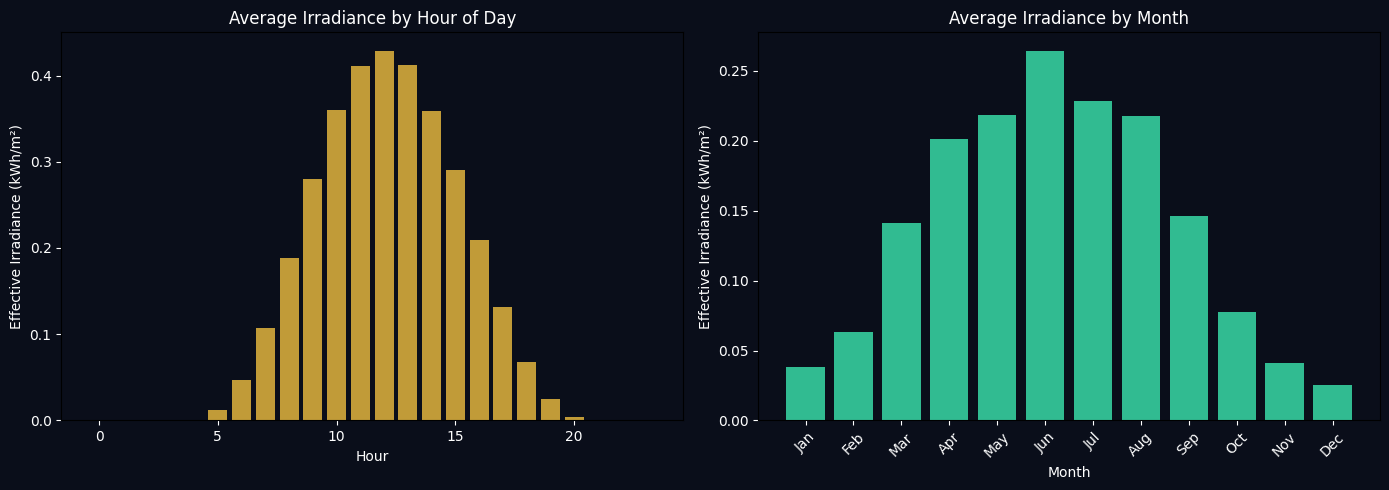

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Average irradiance by hour of day
hourly_avg = weather.groupby("hour")["effective_irradiance"].mean()
axes[0].bar(hourly_avg.index, hourly_avg.values, color="#f0c040", alpha=0.8)
axes[0].set_title("Average Irradiance by Hour of Day")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Effective Irradiance (kWh/m²)")
axes[0].set_facecolor("#0a0e1a")
fig.patch.set_facecolor("#0a0e1a")
for ax in axes:
    ax.tick_params(colors="white")
    ax.title.set_color("white")
    ax.xaxis.label.set_color("white")
    ax.yaxis.label.set_color("white")

# Average irradiance by month
monthly_avg = weather.groupby("month")["effective_irradiance"].mean()
months = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
axes[1].bar(monthly_avg.index, monthly_avg.values, color="#3be8b0", alpha=0.8)
axes[1].set_title("Average Irradiance by Month")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Effective Irradiance (kWh/m²)")
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(months, rotation=45)
axes[1].set_facecolor("#0a0e1a")

plt.tight_layout()
plt.show()

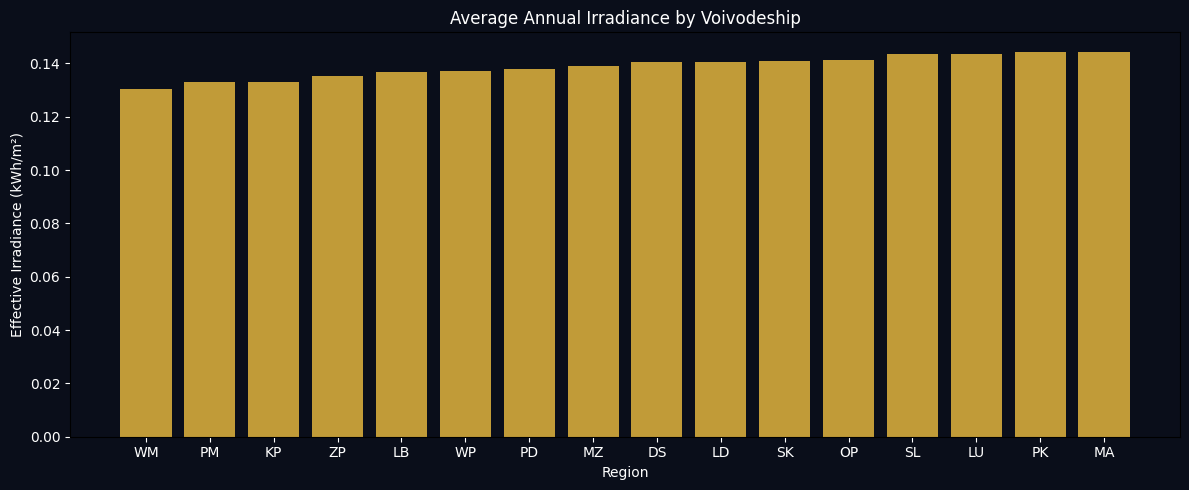


Regional ranking (lowest → highest):
  WM: 0.1305 kWh/m²
  PM: 0.1329 kWh/m²
  KP: 0.1331 kWh/m²
  ZP: 0.1352 kWh/m²
  LB: 0.1368 kWh/m²
  WP: 0.1372 kWh/m²
  PD: 0.1379 kWh/m²
  MZ: 0.1391 kWh/m²
  DS: 0.1405 kWh/m²
  LD: 0.1406 kWh/m²
  SK: 0.1409 kWh/m²
  OP: 0.1412 kWh/m²
  SL: 0.1435 kWh/m²
  LU: 0.1437 kWh/m²
  PK: 0.1442 kWh/m²
  MA: 0.1444 kWh/m²


In [5]:
# Do southern regions really get more irradiance than northern ones?
# This should confirm the gradient in the TypeScript data file
regional_avg = weather.groupby("region_id")["effective_irradiance"].mean().sort_values()

plt.figure(figsize=(12, 5), facecolor="#0a0e1a")
bars = plt.bar(regional_avg.index, regional_avg.values, color="#f0c040", alpha=0.8)
plt.title("Average Annual Irradiance by Voivodeship", color="white")
plt.xlabel("Region", color="white")
plt.ylabel("Effective Irradiance (kWh/m²)", color="white")
plt.tick_params(colors="white")
plt.gca().set_facecolor("#0a0e1a")
plt.tight_layout()
plt.show()

print("\nRegional ranking (lowest → highest):")
for region, val in regional_avg.items():
    print(f"  {region}: {val:.4f} kWh/m²")

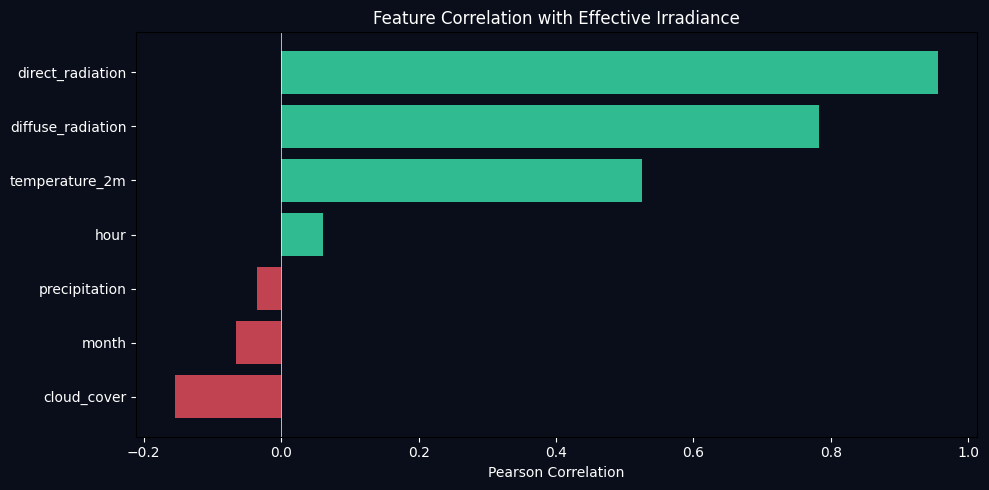

In [6]:
# This tells us which inputs will be most useful to the model
features_to_check = [
    "direct_radiation", "diffuse_radiation", "cloud_cover",
    "temperature_2m", "precipitation", "hour", "month"
]

correlations = weather[features_to_check + ["effective_irradiance"]].corr()["effective_irradiance"].drop("effective_irradiance").sort_values()

plt.figure(figsize=(10, 5), facecolor="#0a0e1a")
colors = ["#f05060" if x < 0 else "#3be8b0" for x in correlations.values]
plt.barh(correlations.index, correlations.values, color=colors, alpha=0.8)
plt.title("Feature Correlation with Effective Irradiance", color="white")
plt.xlabel("Pearson Correlation", color="white")
plt.tick_params(colors="white")
plt.gca().set_facecolor("#0a0e1a")
plt.axvline(0, color="white", linewidth=0.5)
plt.tight_layout()
plt.show()

In [7]:
#tells us we could potentially simplify the feature set. 
#If we only used direct_radiation and diffuse_radiation as inputs, the model would already be very good.
#Everything else is refinement. This is useful to know because simpler models are easier to export to JSON and run in the browser.